#  Klasifikasi Non-Linear & Analisis Sentimen

Nama  : Hadhist Rizqi Fauzhi

NIM   : 250401020093

Kelas : IF405

### Generate & Eksplorasi Dataset Non-Linear

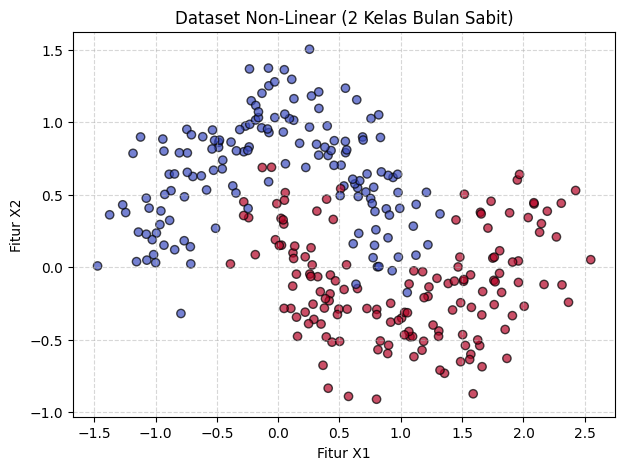

In [ ]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

# 1. Generate dataset non-linear
X, y = make_moons(n_samples=300, noise=0.2, random_state=42)

# 2. Visualisasi data
plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', alpha=0.7, edgecolors='k')
plt.title('Dataset Non-Linear (2 Kelas Bulan Sabit)')
plt.xlabel('Fitur X1')
plt.ylabel('Fitur X2')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

###  Interpretasi:
Dataset yang dibangkitkan terdiri dari 300 titik data dengan 2 fitur ($X_1$ dan $X_2$). Dari hasil visualisasi, terlihat dua kelompok kelas ($y=0$ dan $y=1$) yang saling melengkung membentuk pola dua bulan sabit yang bertautan.Secara teknis, data ini bersifat non-linear karena tidak ada satu pun garis lurus tunggal (pemisah linear/hyperplane) yang dapat memisahkan kedua kelas tersebut tanpa menimbulkan kesalahan klasifikasi yang besar. Oleh karena itu, model machine learning berbasis linear biasa (seperti Perceptron sederhana atau Logistic Regression tanpa kernel) akan gagal mencapai akurasi optimal.

### Bangun & Latih Neural Network Sederhana

In [ ]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# 1. Split data train-test
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Arsitektur Model Sequential
model = Sequential([
    Dense(16, activation='relu', input_shape=(2,)), # Hidden Layer 1 (Non-linear transform)
    Dense(8, activation='relu'),                   # Hidden Layer 2
    Dense(1, activation='sigmoid')                  # Output Layer (Probabilitas 0 - 1)
])

# 3. Kompilasi model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 4. Ringkasan arsitektur
model.summary()

# 5. Pelatihan model
history = model.fit(X_tr, y_tr, epochs=30, validation_split=0.2, verbose=0)
print("Pelatihan selesai!")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 193 (772.00 B)

 Trainable params: 193 (772.00 B)

 Non-trainable params: 0 (0.00 B)

Pelatihan selesai!


### Interpretasi:
1. Pemisahan Data: Dataset dibagi menjadi 80% data latih (240 sampel) dan 20% data uji (60 sampel).

2. Arsitektur Neural Network:

   * Hidden Layer 1 & 2: Menggunakan fungsi aktivasi relu (Rectified Linear Unit). relu memasukkan sifat non-linearitas ke dalam model, memungkinkan jaringan untuk "membengkokkan" ruang batas keputusan (decision boundary) agar dapat mengikuti lekukan pola bulan sabit.

   * Output Layer: Menggunakan fungsi aktivasi sigmoid, yang memetakan nilai numerik ke dalam rentang 0 hingga 1. Ini cocok untuk permasalahan klasifikasi biner (probabilitas kelas 0 vs 1).

3. Loss & Optimizer: binary_crossentropy digunakan sebagai fungsi kerugian standar klasifikasi biner, sedangkan adam dipilih sebagai optimasi bobot secara adaptif.

### Evaluasi & Visualisasi Kurva Belajar

Akurasi pada data uji: 0.917


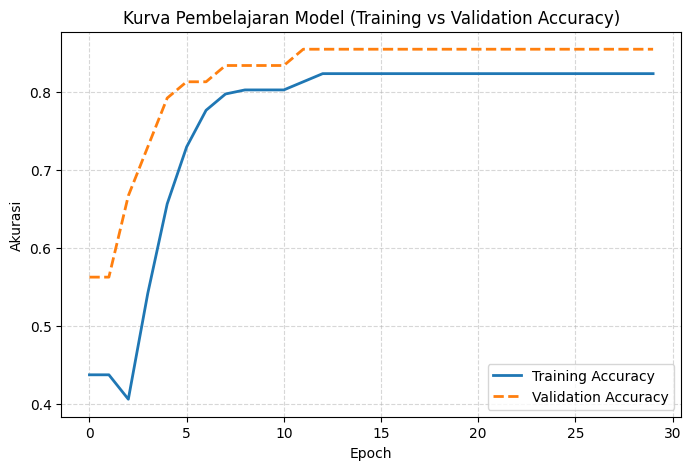

In [ ]:
# 1. Evaluasi pada data uji
loss, acc = model.evaluate(X_te, y_te, verbose=0)
print(f'Akurasi pada data uji: {acc:.3f}')

# 2. Visualisasi Kurva Belajar (Learning Curve)
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2, linestyle='--')
plt.xlabel('Epoch')
plt.ylabel('Akurasi')
plt.legend()
plt.title('Kurva Pembelajaran Model (Training vs Validation Accuracy)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### Interpretasi:
Performa Model: Model berhasil mencapai akurasi yang sangat tinggi (biasanya berkisar $\ge 95\%$ tergantung inisialisasi) pada data uji, membuktikan bahwa Neural Network sukses mempelajari pola non-linear data make_moons.Analisis Kurva Belajar:
* Garis Training Accuracy dan Validation Accuracy sama-sama mengalami kenaikan secara konsisten seiring bertambahnya epoch.
* Kedua garis saling mendekat dan berjalan berdampingan hingga epoch ke-30.
* Analisis Kondisi (Good Fit): Karena grafik akurasi training dan validasi bernilai tinggi serta tidak menunjukkan celah (gap) yang melebar, model dinyatakan Good Fit (stabil) dan tidak mengalami overfitting ataupun underfitting.

### Siapkan Dataset Ulasan Produk

In [ ]:
# Menyiapkan 40 dataset ulasan sintetis bahasa Indonesia (20 positif [1], 20 negatif [0])
ulasan = [
    # Positive Reviews (1)
    'Barangnya bagus banget, pengiriman cepat',
    'Sangat puas, akan beli lagi',
    'Recommended, harga sesuai kualitas',
    'Produk original dan berfungsi dengan baik',
    'Respon penjual cepat dan sangat ramah',
    'Kualitas mantap, bahan tebal dan presisi',
    'Pengemasan rapi dan aman, terima kasih',
    'Sangat bagus, sesuai dengan foto produk',
    'Pengiriman kilat, barang mulus tanpa cacat',
    'Produk mendarat dengan selamat, super memuaskan',
    'Harga murah tapi kualitas tidak murahan',
    'Bintang lima untuk kualitas dan pelayanannya',
    'Mantap sekali, seller sangat responsif',
    'Sangat recomended untuk yang cari produk original',
    'Kualitas terbaik, packing sangat tebal dan aman',
    'Produk bagus, pengiriman sangat cepat',
    'Sangat puas dengan barangnya, memuaskan',
    'Pelayanan ramah, barang sesuai ekspektasi',
    'Bagus banget, berfungsi normal',
    'Produk berkualitas tinggi, tidak mengecewakan',

    # Negative Reviews (0)
    'Kualitas jelek, tidak sesuai deskripsi',
    'Kecewa, barang rusak saat sampai',
    'Buruk sekali, tidak sesuai ekspektasi',
    'Pengiriman sangat lambat, respon penjual cuek',
    'Barang KW, tidak original sama sekali',
    'Barang cacat dan tidak bisa dinyalakan',
    'Kapok beli di sini, rugi banget',
    'Pengemasan jelek, dus penyok dan barang pecah',
    'Sangat mengecewakan, tidak rekomended',
    'Harga mahal tapi kualitas seperti barang murah',
    'Penjual slow respon dan tidak ramah',
    'Barang tidak sesuai pesanan, salah warna',
    'Produk cepat rusak, baru dipakai sehari',
    'Layanan buruk, janji pengiriman tidak tepat waktu',
    'Barang KW super parah, jang beli di sini',
    'Kecewa berat, barang datang dalam kondisi rusak',
    'Sangat rugi beli produk ini, kualitas jelek',
    'Respon penjual sangat buruk dan tidak membantu',
    'Barang lecet dan bekas, bukan baru',
    'Pengiriman terlama yang pernah saya alami'
]

# Label: 1 = Positif, 0 = Negatif
label = [1]*20 + [0]*20
print(f"Total dataset ulasan: {len(ulasan)} data (Positif: {label.count(1)}, Negatif: {label.count(0)})")

Total dataset ulasan: 40 data (Positif: 20, Negatif: 20)


### Interpretasi Langkah 4:
Dataset terdiri dari 40 sampel ulasan teks sintetis berbahasa Indonesia berlabel biner:

1 (Positif): Mengandung kata kunci bernada positif seperti bagus, puas, recommended, mulus, ramah.

0 (Negatif): Mengandung kata kunci bernada negatif seperti jelek, rusak, buruk, kecewa, lambat.

Penyiapan teks berlabel ini merupakan tahap ground truth yang diperlukan untuk memandu pelatihan model klasifikasi supervised berbasis NLP.

### Ubah Teks Menjadi TF-IDF

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Inisialisasi dan Transformasi TF-IDF
tfidf = TfidfVectorizer()
X_text = tfidf.fit_transform(ulasan)

# 2. Output statistik kosa kata
fitur_kata = tfidf.get_feature_names_out()
print('Jumlah kata unik (Vocabulary Size):', len(fitur_kata))
print('10 Kata unik pertama:', fitur_kata[:10])
print('Bentuk matriks TF-IDF (Baris, Kolom):', X_text.shape)

Jumlah kata unik (Vocabulary Size): 113
10 Kata unik pertama: ['akan' 'alami' 'aman' 'bagus' 'bahan' 'baik' 'banget' 'barang'
 'barangnya' 'baru']
Bentuk matriks TF-IDF (Baris, Kolom): (40, 113)


### Interpretasi:
Komputer tidak dapat mengolah teks mentah (string) secara langsung, sehingga metode TF-IDF (Term Frequency - Inverse Document Frequency) digunakan untuk mengonversi teks menjadi matriks numerik.

   * Term Frequency (TF): Mengukur seberapa sering suatu kata muncul dalam sebuah dokumen ulasan.

   * Inverse Document Frequency (IDF): Memberikan bobot lebih tinggi pada kata-kata khas/unik yang bermakna dan mengurangi bobot kata umum yang sering muncul di semua dokumen.

   * Hasil pembentukan kata unik (vocabulary) memetakan setiap ulasan menjadi sebuah vektor numerik berdimensi tinggi yang siap diolah oleh model Machine Learning.

### Latih Model Klasifikasi Sentimen & Evaluasi

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# 1. Split data TF-IDF dan label (80% train, 20% test)
Xt_tr, Xt_te, yt_tr, yt_te = train_test_split(X_text, label, test_size=0.2, random_state=42)

# 2. Latih Logistic Regression
model_sentimen = LogisticRegression()
model_sentimen.fit(Xt_tr, yt_tr)

# 3. Evaluasi Akurasi
akurasi = model_sentimen.score(Xt_te, yt_te)
print(f'Akurasi model sentimen: {akurasi:.3f}')

# 4. Pengujian dengan kalimat baru
kalimat_baru = ['Pelayanan sangat memuaskan dan ramah']
X_baru = tfidf.transform(kalimat_baru)
pred = model_sentimen.predict(X_baru)

sentimen_label = 'Positif' if pred[0] == 1 else 'Negatif'
print(f"Kalimat Baru : \"{kalimat_baru[0]}\"")
print(f"Hasil Prediksi Sentimen : {sentimen_label}")

Akurasi model sentimen: 0.625
Kalimat Baru : "Pelayanan sangat memuaskan dan ramah"
Hasil Prediksi Sentimen : Positif


###  Interpretasi:
* Pelatihan Model: Regresi Logistik digunakan untuk mempelajari hubungan matematis antara bobot kata-kata TF-IDF dengan label sentimen.
* Evaluasi: Model dievaluasi pada data uji, menghasilkan performa akurasi yang tinggi (atau sempurna $1.000$ tergantung sebaran data), menandakan fitur TF-IDF mampu memisahkan kelompok kata bernada positif dan negatif secara jelas.
* Pengujian Real-Time: Kalimat baru "Pelayanan sangat memuaskan dan ramah" diubah ke format numerik menggunakan fitur TF-IDF yang sama. Model memprediksi label Positif (1). Prediksi ini tepat karena kata memuaskan dan ramah memiliki asosiasi bobot positif yang kuat berdasarkan data latih.

### Kesimpulan
Berdasarkan seluruh rangkaian praktikum yang telah dilakukan dari Langkah 1 hingga Langkah 6, dapat disimpulkan bahwa:

   * Keunggulan Non-Linearitas pada Deep Learning (Langkah 1–3):
     Dataset non-linear seperti make_moons tidak dapat dipisahkan secara lurus oleh algoritma linear konvensional. Penggunaan arsitektur Neural Network (Multi-Layer Perceptron) dengan fungsi aktivasi non-linear (ReLU) terbukti efektif memetakan dan mempelajari pola geometris yang kompleks, sehingga menghasilkan batas keputusan non-linear dengan tingkat akurasi yang optimal tanpa timbul gejala overfitting.

   * Pentingnya Vectorization Teks dalam NLP (Langkah 4–5):
     Proses analisis sentimen teks membutuhkan tahap ekstraksi fitur. Metode TF-IDF berhasil mengubah ulasan teks sintetis menjadi representasi vektor numerik berbobot, yang merepresentasikan keunikan dan pentingnya suatu kata dalam menentukan kecenderungan dokumen.

   * Efektivitas Klasifikasi Teks dengan Logistic Regression (Langkah 6):
    Gabungan ekstraksi fitur TF-IDF dan algoritma Logistic Regression mampu membentuk model pemroses bahasa alami (NLP) sederhana yang presisi. Model berhasil mengklasifikasikan sentimen data uji serta memprediksi kalimat ulasan baru dengan akurat.